# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 28     |  |
| :-------------|:-------------|
| Student Korné Hoendervangers| 6466826 |
| Lucas Plasman| 6545165 |
| Vera Reeringh| 6321046 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Korné', 'Lucas','Vera']

## Opdracht 1: Planning.

| Planning Groep: 28     |Tijdstip / Tijdspanne  |
|---|---|
| kaliberen sensor | 11:15 |
| Meetopstelling getest | 12:30 |
| Na pauze uitvoeren van de zelf bedachte algoritme|14:00 gedaan|
| Algoritme verbeteren|15:00|
|Laatste metingen met eindalgoritme|16:00|
| groep aanwezig voor pauze| 2 uur |
| groep aanwezig na pauze| resterende tijd van de dag |
| Pauze 1| 1 uur om 12:30 |
| Pauze 2| 15 minuten als nodig |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
from scipy.optimize import curve_fit

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [28]
<img src="opstelling2.jpg" width="400">

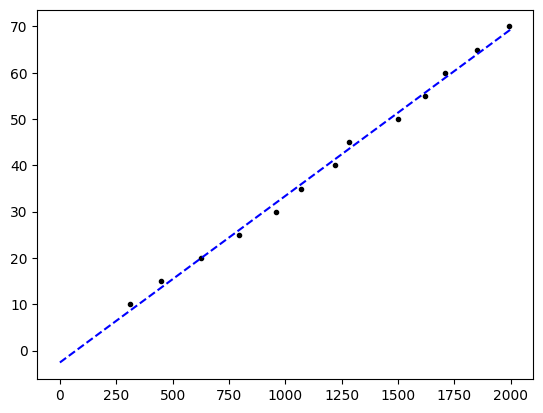

0.03597815649450576 -2.5704617740666764


In [3]:
# verwerk hier jullie kalibratiemetingen
Kalibratie_afstand = np.array([0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7])*100 #afstand in meter
Kalibratie_signaal = np.array([310,450,625,795,960,1070,1220,1282,1500,1620,1710,1850,1990]) #signaal van de arduino

v = Kalibratie_afstand/Kalibratie_signaal

def snelheid(A,t):
    return A/t

def func(a,x,b):
    y = a * x + b
    return y

Tijd = np.linspace(0,2000, 2000)
popt,pcov = curve_fit(func,Kalibratie_signaal,Kalibratie_afstand)

afstand = popt[0]*Tijd + popt[1]

plt.figure()
plt.plot(Kalibratie_signaal,Kalibratie_afstand,'k.')
plt.plot(Tijd, afstand,"b--")
plt.show()
print(popt[0],popt[1])


## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  42.1
1   0  30   0  20  40.5
2  40   0  30   0  46.5
3  30   0  20   0  51.1


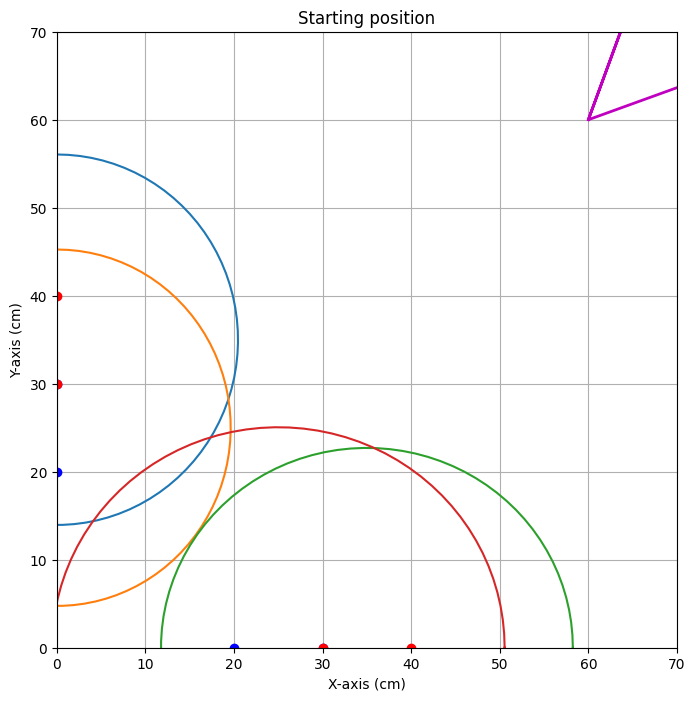


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=96.905


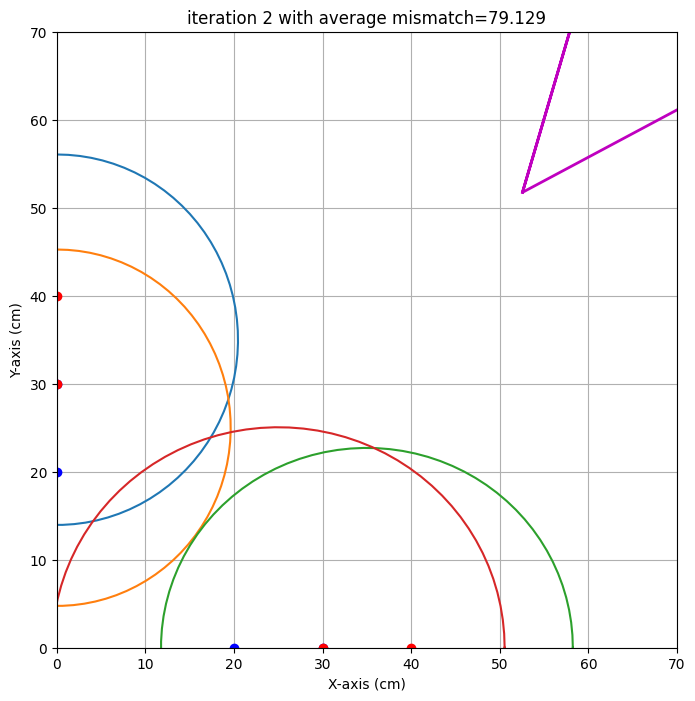

end iteration 2 with average mismatch=79.129


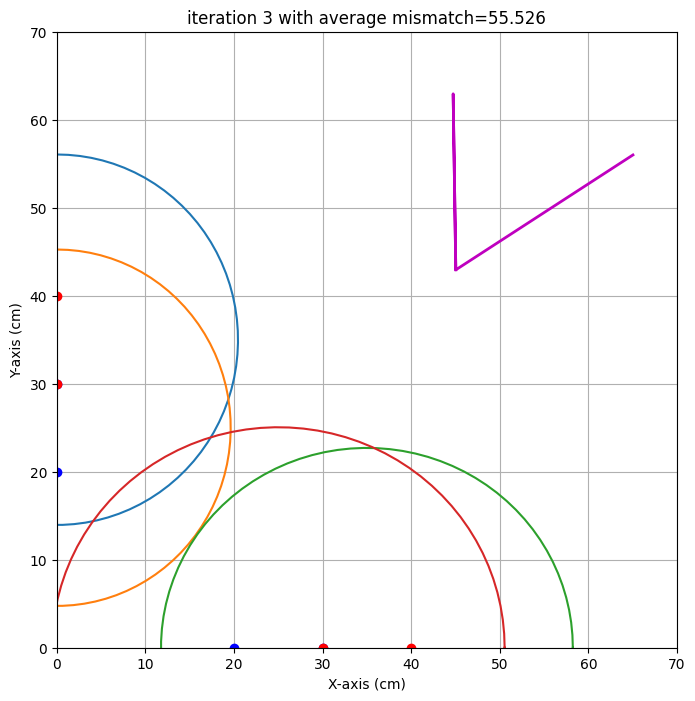

end iteration 3 with average mismatch=55.526


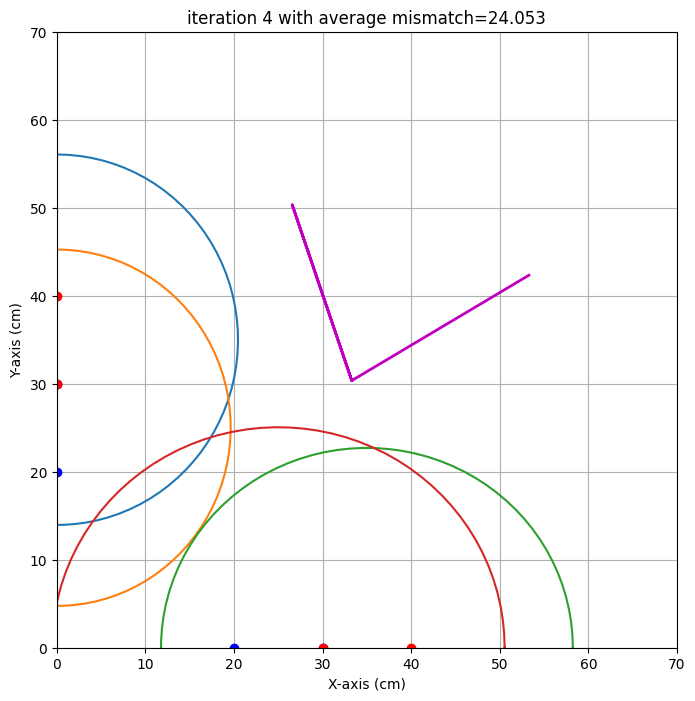

end iteration 4 with average mismatch=24.053


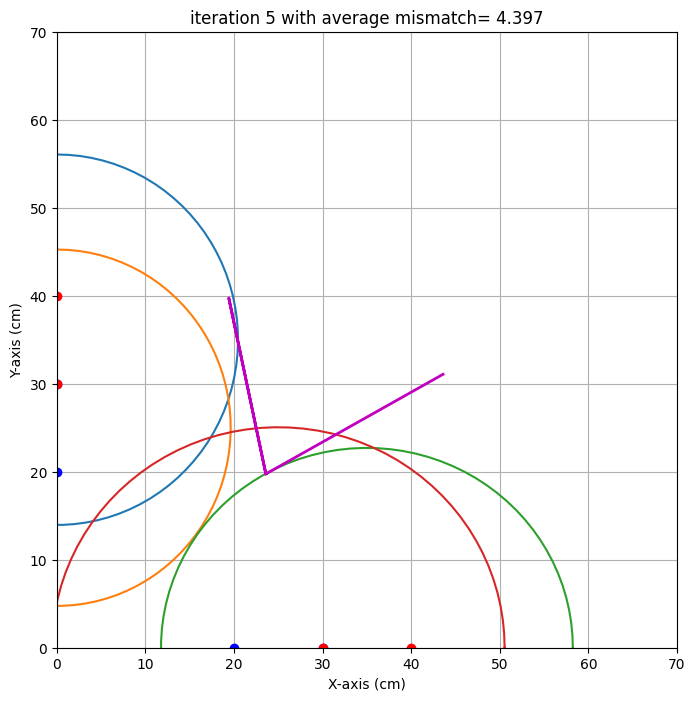

end iteration 5 with average mismatch= 4.397


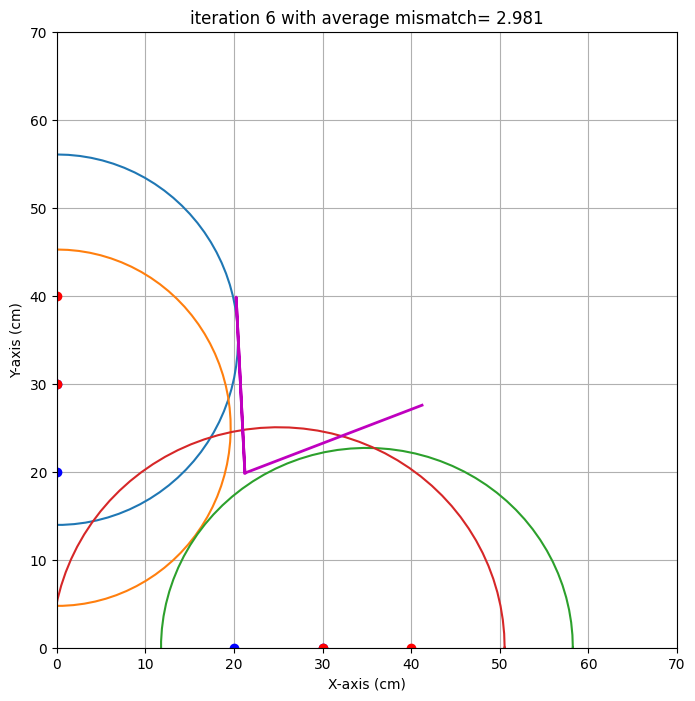

end iteration 6 with average mismatch= 2.981


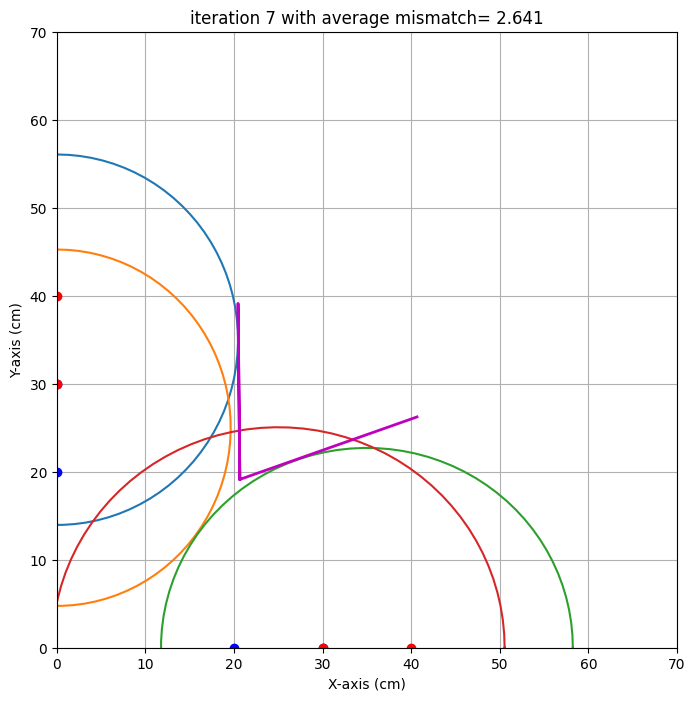

end iteration 7 with average mismatch= 2.641
end iteration 8 with average mismatch= 2.512


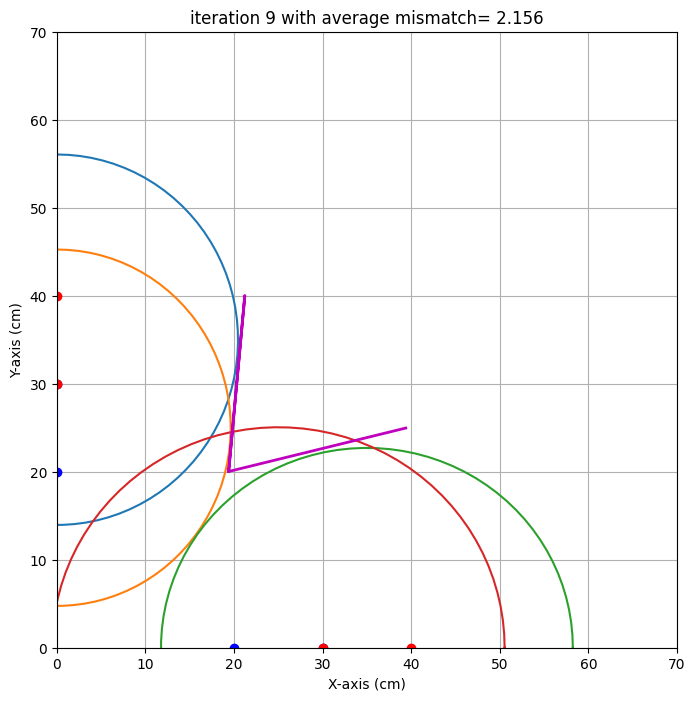

end iteration 9 with average mismatch= 2.156


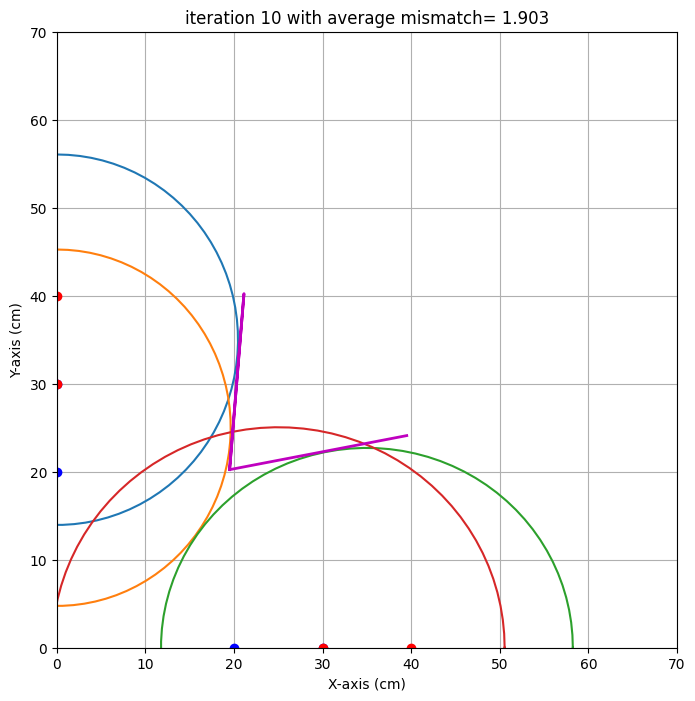

end iteration 10 with average mismatch= 1.903
end iteration 11 with average mismatch= 1.831
end iteration 12 with average mismatch= 1.792
end iteration 13 with average mismatch= 1.790
end iteration 14 with average mismatch= 1.790
end iteration 15 with average mismatch= 1.790
end iteration 16 with average mismatch= 1.790
end iteration 17 with average mismatch= 1.790
end iteration 18 with average mismatch= 1.790
end iteration 19 with average mismatch= 1.790
end iteration 20 with average mismatch= 1.790
end iteration 21 with average mismatch= 1.790
end iteration 22 with average mismatch= 1.790
end iteration 23 with average mismatch= 1.790
end iteration 24 with average mismatch= 1.790
end iteration 25 with average mismatch= 1.790
end iteration 26 with average mismatch= 1.790
end iteration 27 with average mismatch= 1.790
end iteration 28 with average mismatch= 1.790
end iteration 29 with average mismatch= 1.790
Last iteration, also determine uncertainty, wait a while..
wait a little longer.

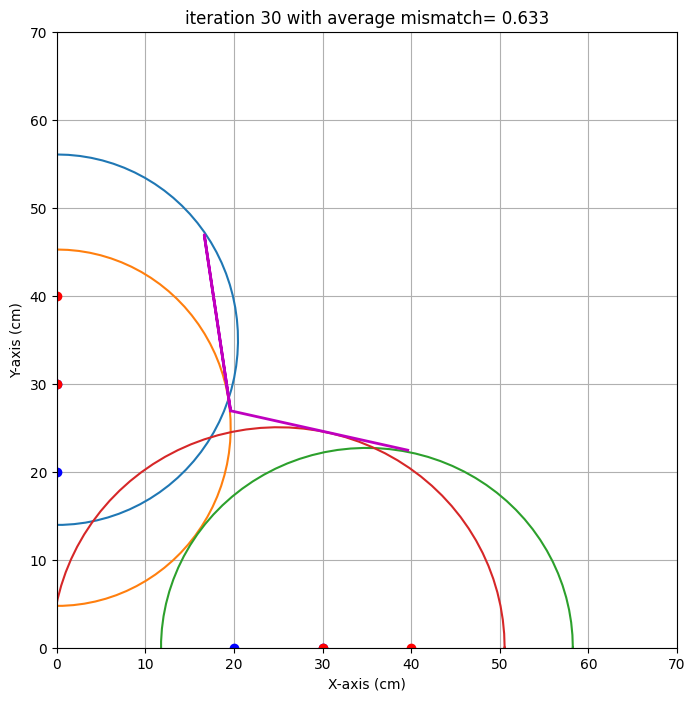

end iteration 30 with average mismatch= 0.633
###############################################################################
end of iteration  30
Best alpha= -12.62 with uncertainty=   0.00
Best beta =  -8.45 with uncertainty=   0.00
Best x0   =  19.61 with uncertainty=   0.00
Best y0   =  26.93 with uncertainty=   0.00
###############################################################################


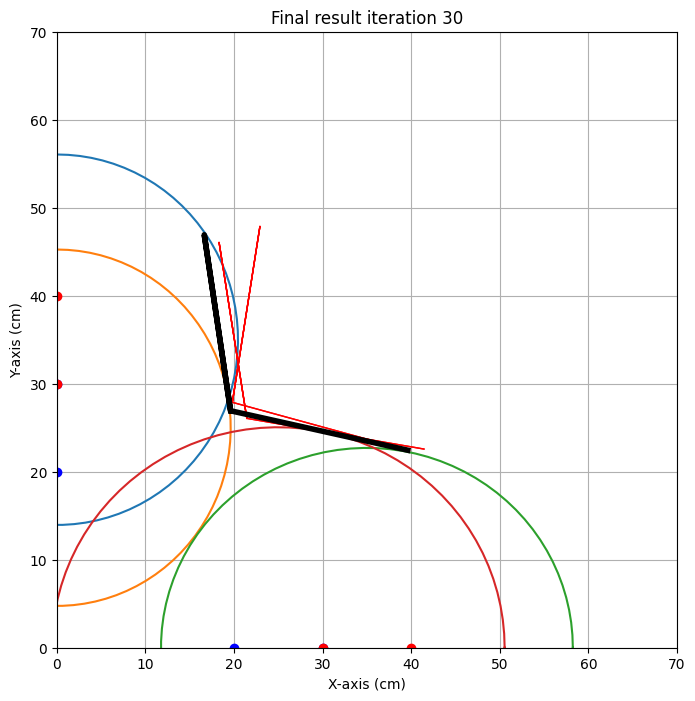

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,42.10],
    [0,30,0,20,40.50],
    # [0,10,0,20,100],#klopt niet is ongeldig
    [40,0,30,0,46.5],
    [30,0,20,0,51.1]
    # [10,0,20,0,120],#te hoog klopt niet is ongeldig
    # [10,0,0,10,120] # ook te hoog klopt niet  
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 19.6 cm met een standaardafwijking van 0.0 cm 
y0: 26.9 cm met een standaardafwijking van 0.0 cm 
alpha: -12.6 graden met een standaardafwijking van 0.0 graad 
beta: -8.5 graden met een standaardafwijking van 0.0 graad 



Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  30    NaN
1   0  30   0  20  41.70
2  40   0  30   0  50.25
3  30   0  20   0  51.60


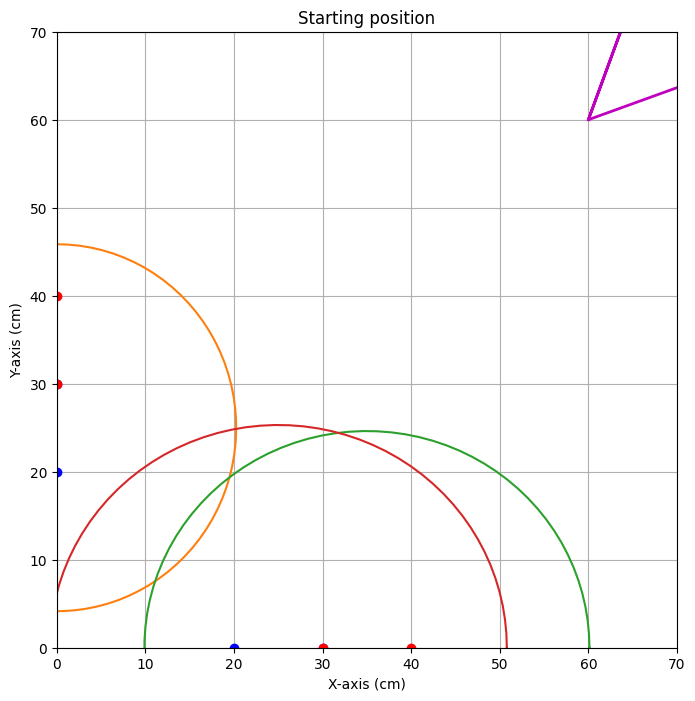


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=   nan
end iteration 2 with average mismatch=   nan
end iteration 3 with average mismatch=   nan
end iteration 4 with average mismatch=   nan
end iteration 5 with average mismatch=   nan
end iteration 6 with average mismatch=   nan
end iteration 7 with average mismatch=   nan
end iteration 8 with average mismatch=   nan
end iteration 9 with average mismatch=   nan
end iteration 10 with average mismatch=   nan
end iteration 11 with average mismatch=   nan
end iteration 12 with average mismatch=   nan
end iteration 13 with average mismatch=   nan
end iteration 14 with average mismatch=   nan
end iteration 15 with average mismatch=   nan
end iteration 16 with average mismatch=   nan
end iteration 17 with average mismatch=   nan
end iteration 18 with average mismatch=   nan
end iteration 19 with average mismatch=   nan
end iteration 20 with average mismatch=   nan
end iteration 21 with ave

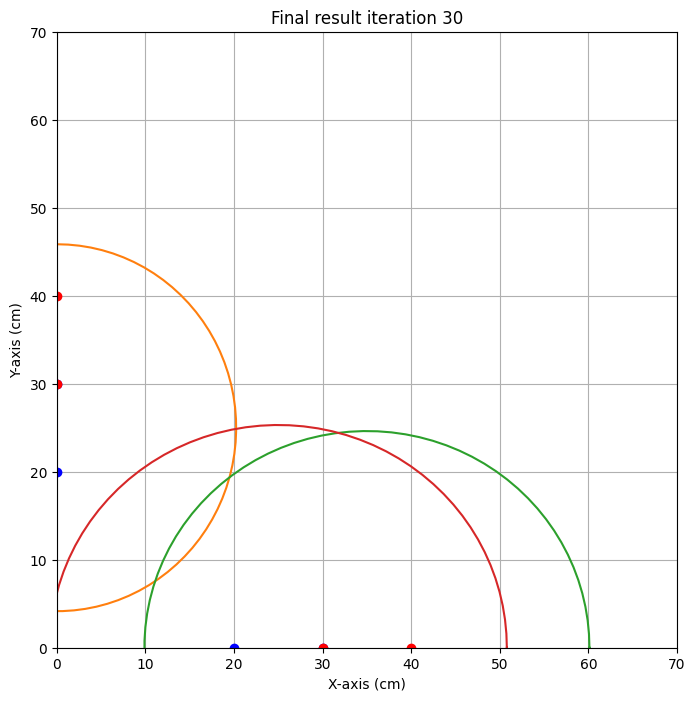

In [6]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,],
    [0,30,0,20,41.70],
    # [0,10,0,20,100],#klopt niet is ongeldig
    [40,0,30,0,50.25],
    [30,0,20,0,51.6]
    # [10,0,20,0,120],#te hoog klopt niet is ongeldig
    # [10,0,0,10,120] # ook te hoog klopt niet  
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

## Opdracht 5: Iteratie 0

#### algoritme [korné ]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="logaritmekorne.jpg" width="400">

#### algoritme [vera]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="logaritmevera.jpg" width="400">

#### algoritme [lucas]
Voeg een foto in van het algoritme van het derde groepslid
<img src="logaritmelucas.jpg" width="400">

In [7]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [8]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 52, 
           'y0': 40, #zelf aanvullen,
           'alpha' :109,  #zelf aanvullen,
           'beta' :82 #zelf aanvullen},
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Vera' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                                [35,0,40,0,105],
                                [60,0,65,0,45],
                              #   [25,0,30,0,Niet nodig],
                                [0,35,0,40,94],
                                [0,40,0,45,94]]),
       'Korné' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                              [0,30,0,40,93],
                              [0,60,0,50,102],
                              #[0,30,0,40,ongeldig],
                              [60,0,50,0,49],
                              [0,35,0,45,94],
                              [0,25,0,35,93],
                              [65,0,55,0,48],
                              [55,0,45,0,49]]),
                              
      'Lucas' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                            # [0,60,0,50,telt niet],
                            [0,30,0,40,49.5],
                            # [30,0,40,0,kan niet],
                            [60,0,50,0,79.5],
                            [35,0,45,0,134.6],
                            [0,25,0,35,50.7],
                            [0,35,0,45,50.1],
                            # [25,0,35,0,kan niet],
                            [45,0,55,0,72.2]
                          
        ])}
        # 'Vera' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
        #                       # [0,30,0,40,telt niet ],
        #                       [0,60,0,50,80],
        #                       [30,0,40,0,104.6],
        #                       [60,0,50,0,100.2],
        #                       [55,0,45,0,100.7],
        #                       [65,0,55,0,104.6],
        #                       [0,65,0,55,76.2],
        #                       [0,55,0,45,87],
        #                       [0,63,0,53,73.7],
        #                       [0,57,0,47,78.1],
        #                       [63,0,53,0,99.6],
        #                       [57,0,47,0,98.7]
        #                         ])}      
                              
                              
            



In [9]:
# #test 2 
# data ={'Vera' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
#                               # [0,30,0,40,telt niet ],
#                               [0,60,0,50,80],
#                               [30,0,40,0,104.6],
#                               [60,0,50,0,100.2],
#                               [55,0,45,0,100.7],
#                               [65,0,55,0,104.6],
#                               [0,65,0,55,76.2],
#                               [0,55,0,45,87]
#                                 ])}

## Opdracht 7: Evaluatie.

Korné
Running the imaging algorithm with the following data:
   xs  ys  xr  yr    R
0   0  30   0  40   93
1   0  60   0  50  102
2  60   0  50   0   49
3   0  35   0  45   94
4   0  25   0  35   93
5  65   0  55   0   48
6  55   0  45   0   49


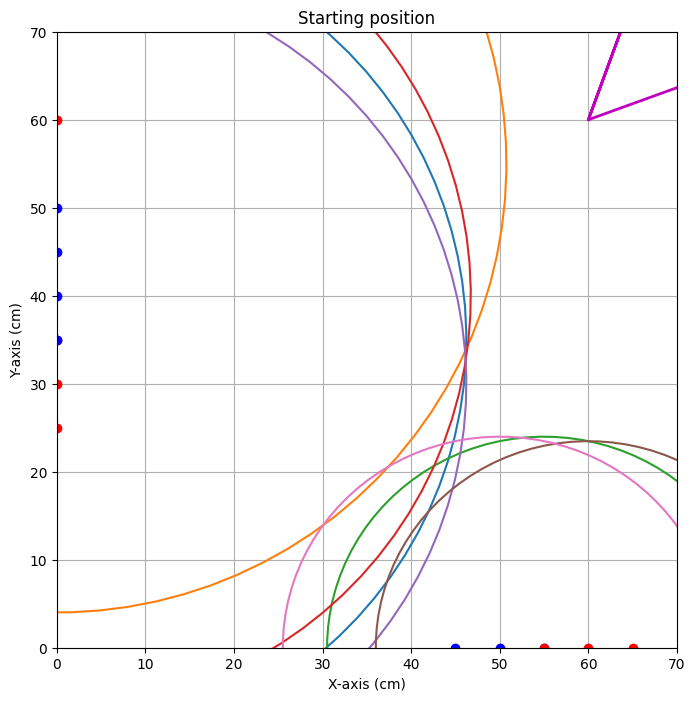


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=56.066


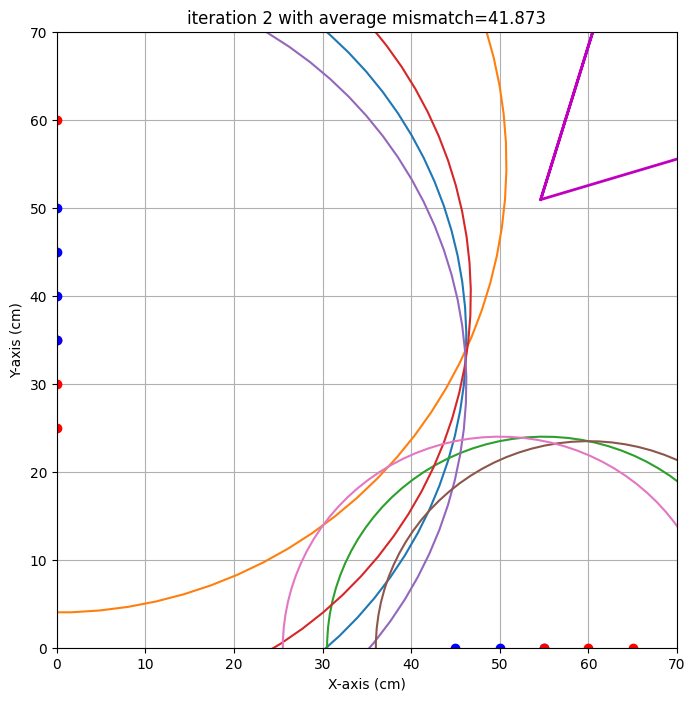

end iteration 2 with average mismatch=41.873


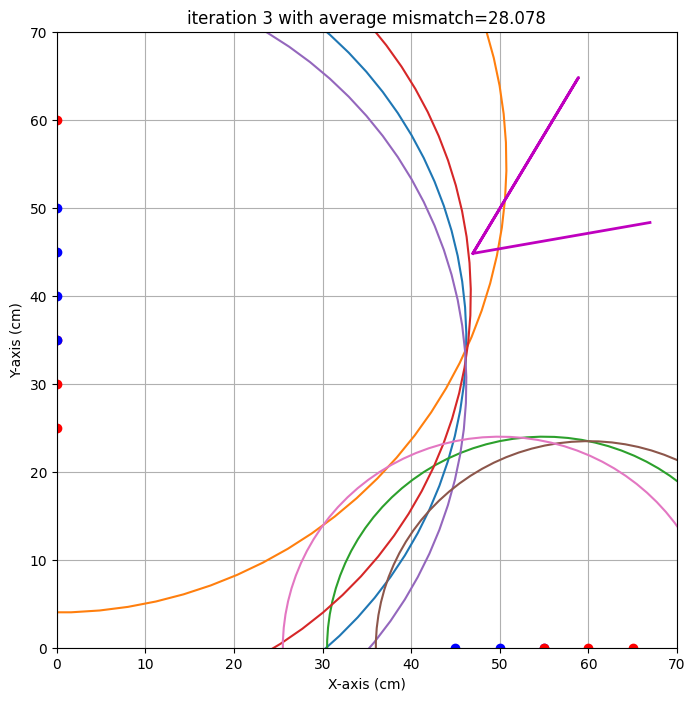

end iteration 3 with average mismatch=28.078


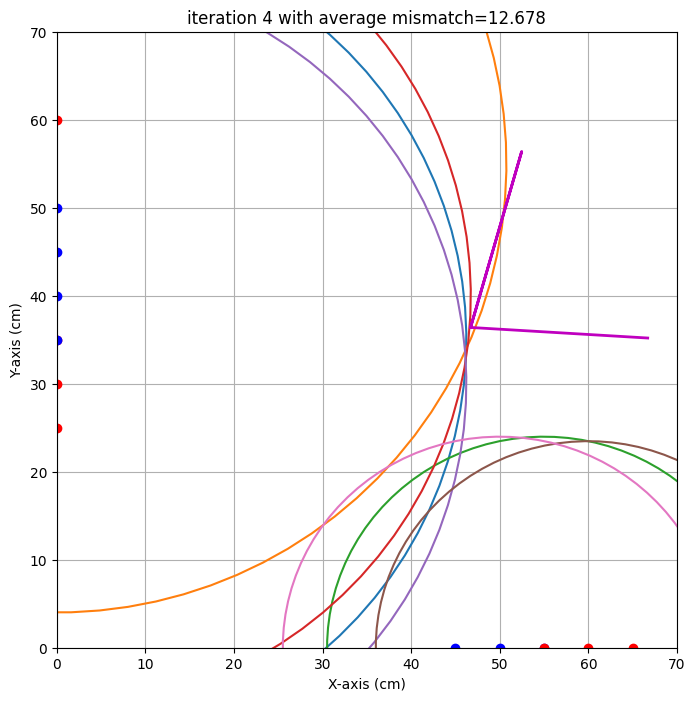

end iteration 4 with average mismatch=12.678


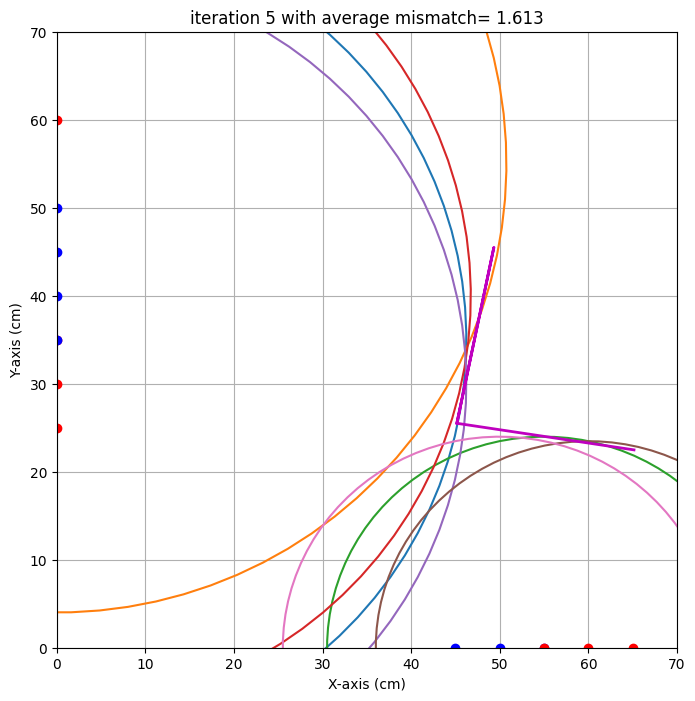

end iteration 5 with average mismatch= 1.613


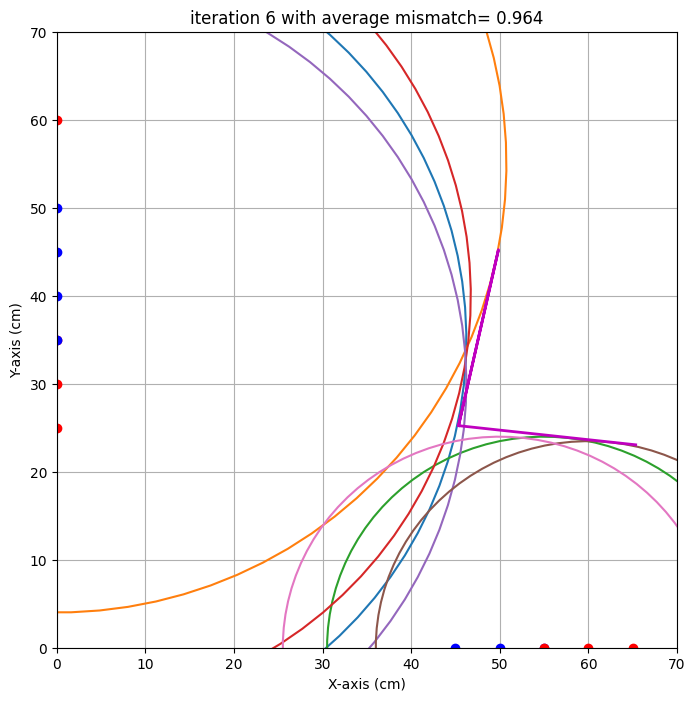

end iteration 6 with average mismatch= 0.964
end iteration 7 with average mismatch= 0.905
end iteration 8 with average mismatch= 0.861
end iteration 9 with average mismatch= 0.860
end iteration 10 with average mismatch= 0.859
end iteration 11 with average mismatch= 0.859
end iteration 12 with average mismatch= 0.859
end iteration 13 with average mismatch= 0.859
end iteration 14 with average mismatch= 0.859
end iteration 15 with average mismatch= 0.859
end iteration 16 with average mismatch= 0.859
end iteration 17 with average mismatch= 0.859
end iteration 18 with average mismatch= 0.859
end iteration 19 with average mismatch= 0.859
end iteration 20 with average mismatch= 0.859
end iteration 21 with average mismatch= 0.859
end iteration 22 with average mismatch= 0.859
end iteration 23 with average mismatch= 0.859
end iteration 24 with average mismatch= 0.859
end iteration 25 with average mismatch= 0.859
end iteration 26 with average mismatch= 0.859
end iteration 27 with average mismatch

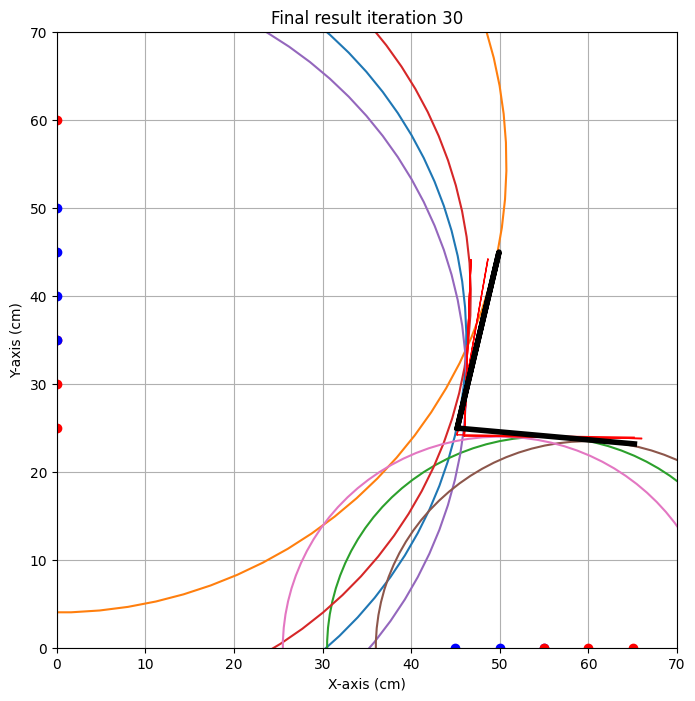

{'alpha': np.float64(-5.137585865772358), 'alpha_eps': np.float64(4.333035469132078), 'beta': np.float64(13.275354505090029), 'beta_eps': np.float64(11.143507975213526), 'x0': np.float64(45.197892293181425), 'x0_eps': np.float64(0.7978474850928876), 'y0': np.float64(24.957302194921358), 'y0_eps': np.float64(0.8661047090697558)}
Lucas
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  30   0  40   49.5
1  60   0  50   0   79.5
2  35   0  45   0  134.6
3   0  25   0  35   50.7
4   0  35   0  45   50.1
5  45   0  55   0   72.2


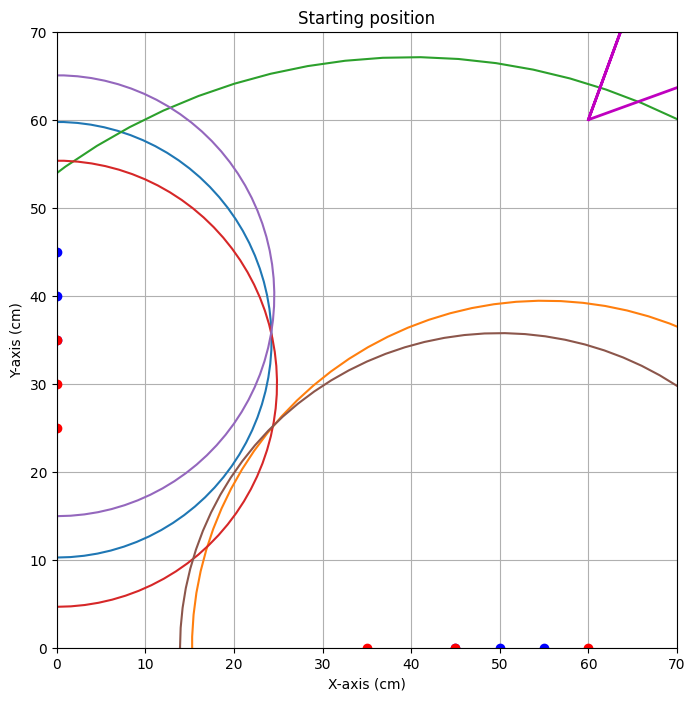


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=62.498


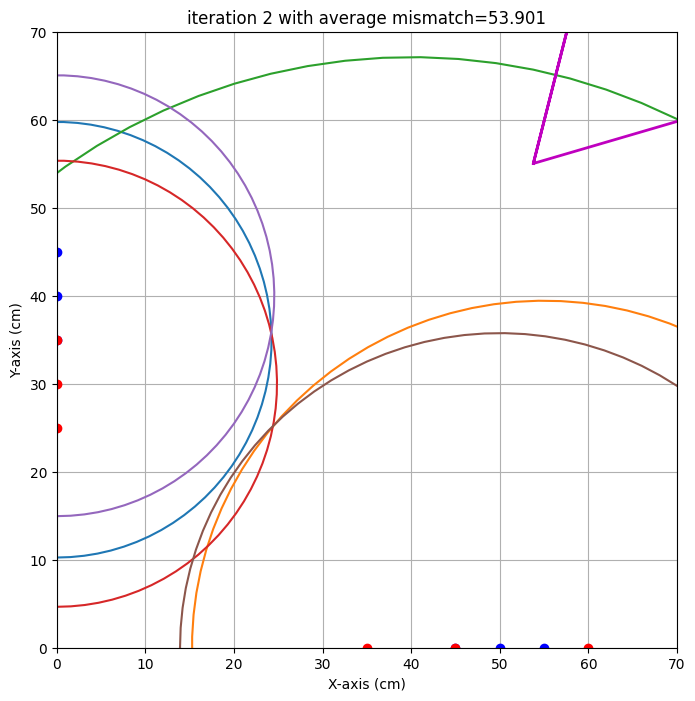

end iteration 2 with average mismatch=53.901


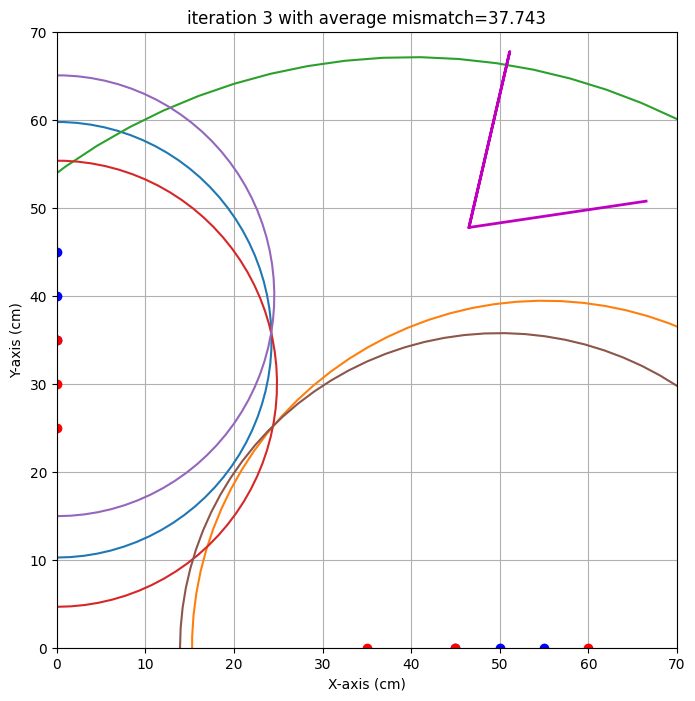

end iteration 3 with average mismatch=37.743


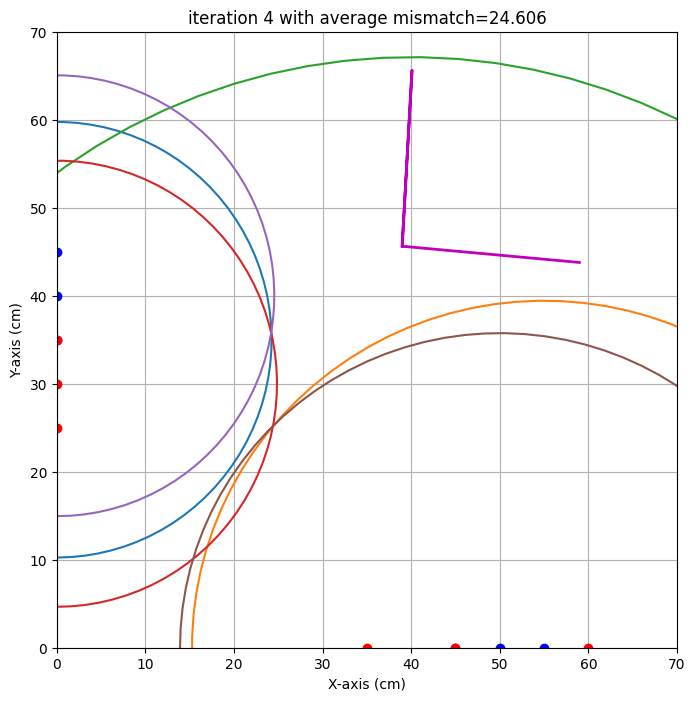

end iteration 4 with average mismatch=24.606


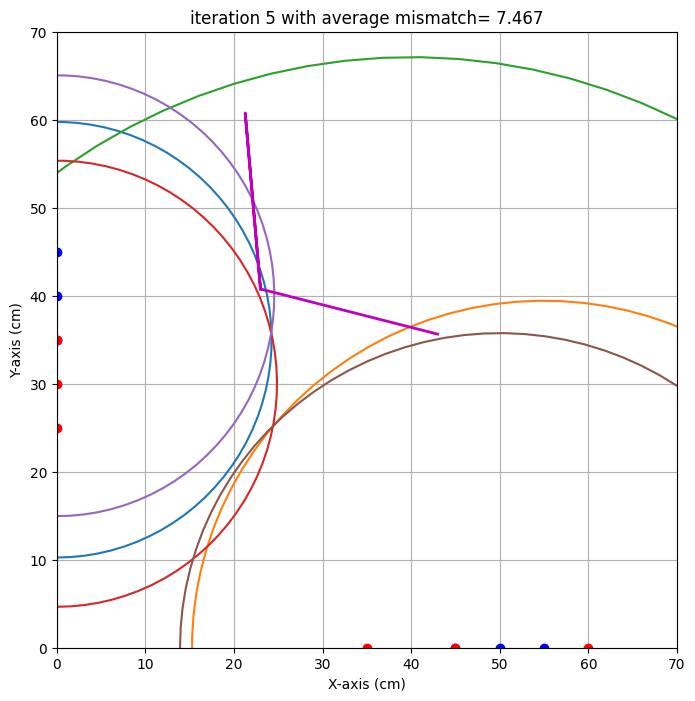

end iteration 5 with average mismatch= 7.467


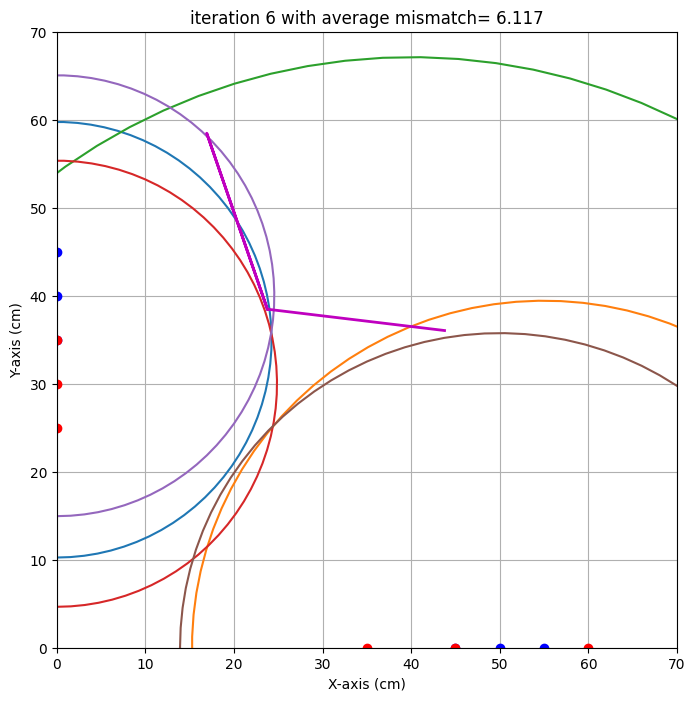

end iteration 6 with average mismatch= 6.117
end iteration 7 with average mismatch= 5.856
end iteration 8 with average mismatch= 5.690
end iteration 9 with average mismatch= 5.610
end iteration 10 with average mismatch= 5.498
end iteration 11 with average mismatch= 5.449
end iteration 12 with average mismatch= 5.449
end iteration 13 with average mismatch= 5.449
end iteration 14 with average mismatch= 5.449
end iteration 15 with average mismatch= 5.327
end iteration 16 with average mismatch= 5.327
end iteration 17 with average mismatch= 5.327
end iteration 18 with average mismatch= 5.327
end iteration 19 with average mismatch= 5.284
end iteration 20 with average mismatch= 5.236
end iteration 21 with average mismatch= 5.236
end iteration 22 with average mismatch= 5.236
end iteration 23 with average mismatch= 5.236
end iteration 24 with average mismatch= 5.236
end iteration 25 with average mismatch= 5.236
end iteration 26 with average mismatch= 5.236
end iteration 27 with average mismatch

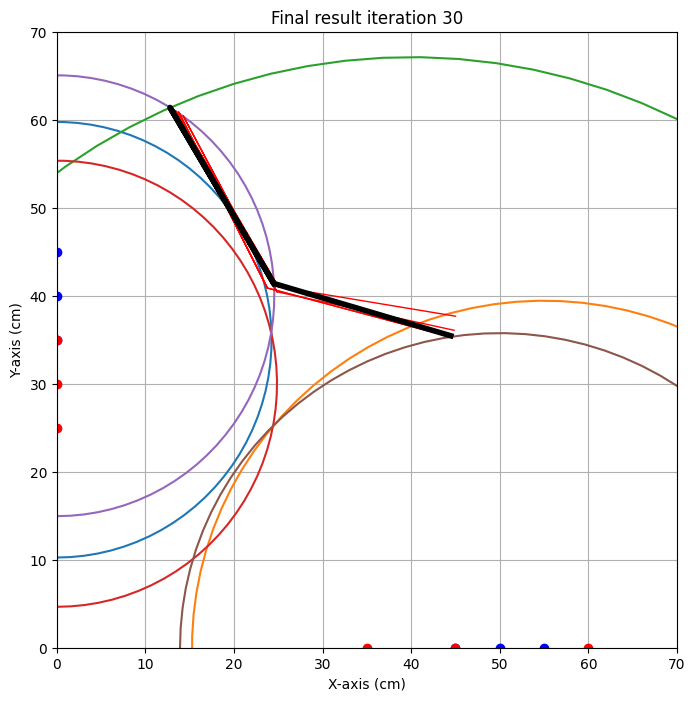

{'alpha': np.float64(-16.563404286406314), 'alpha_eps': np.float64(7.071925484677909), 'beta': np.float64(-30.351745131379143), 'beta_eps': np.float64(3.758154510620553), 'x0': np.float64(24.476064411041083), 'x0_eps': np.float64(0.7216686530775327), 'y0': np.float64(41.395736413076435), 'y0_eps': np.float64(0.9455166454954593)}
Vera
Running the imaging algorithm with the following data:
   xs  ys  xr  yr    R
0  35   0  40   0  105
1  60   0  65   0   45
2   0  35   0  40   94
3   0  40   0  45   94


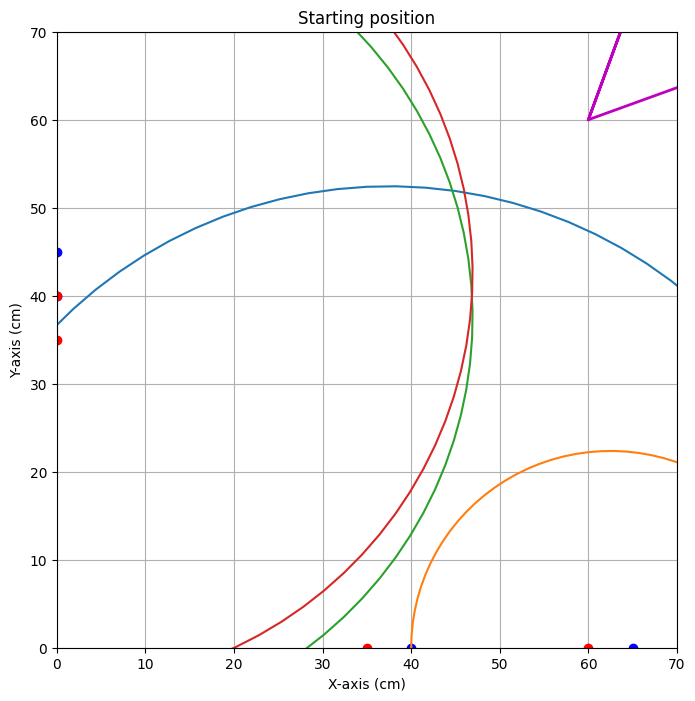


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=47.674


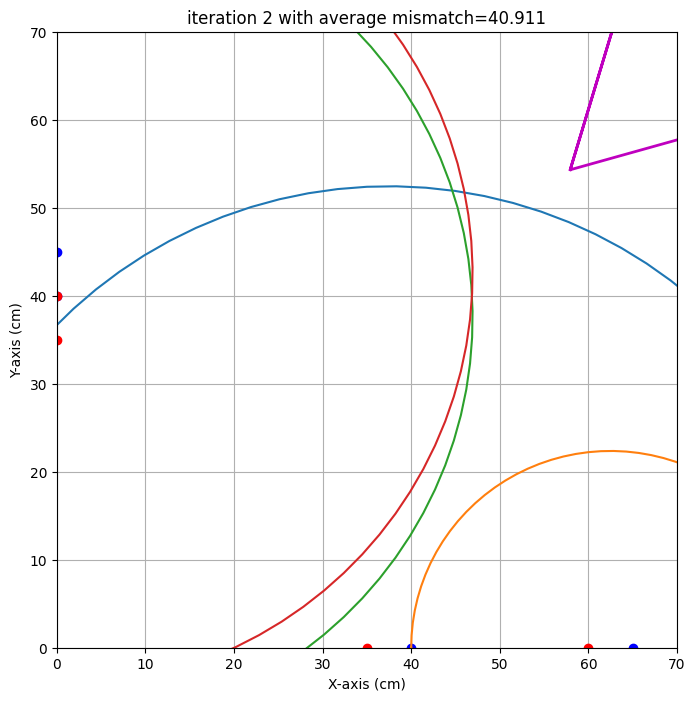

end iteration 2 with average mismatch=40.911


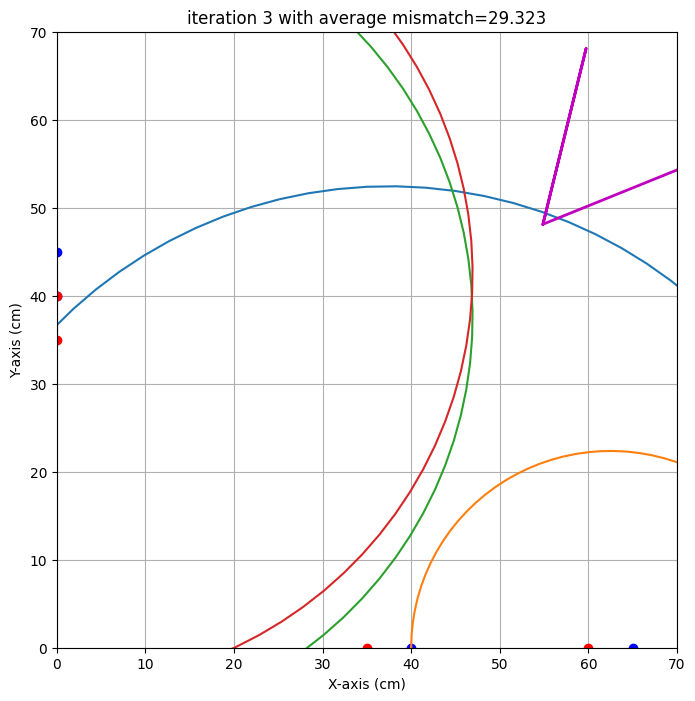

end iteration 3 with average mismatch=29.323


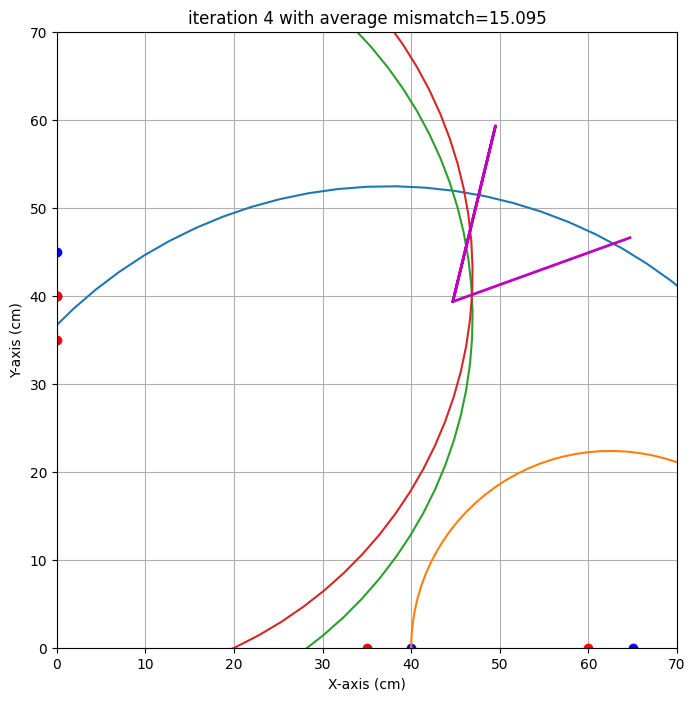

end iteration 4 with average mismatch=15.095


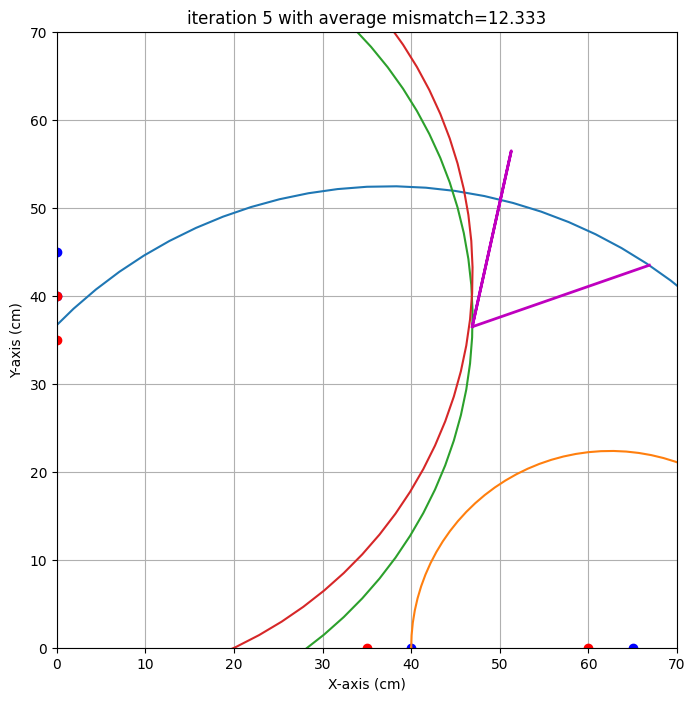

end iteration 5 with average mismatch=12.333


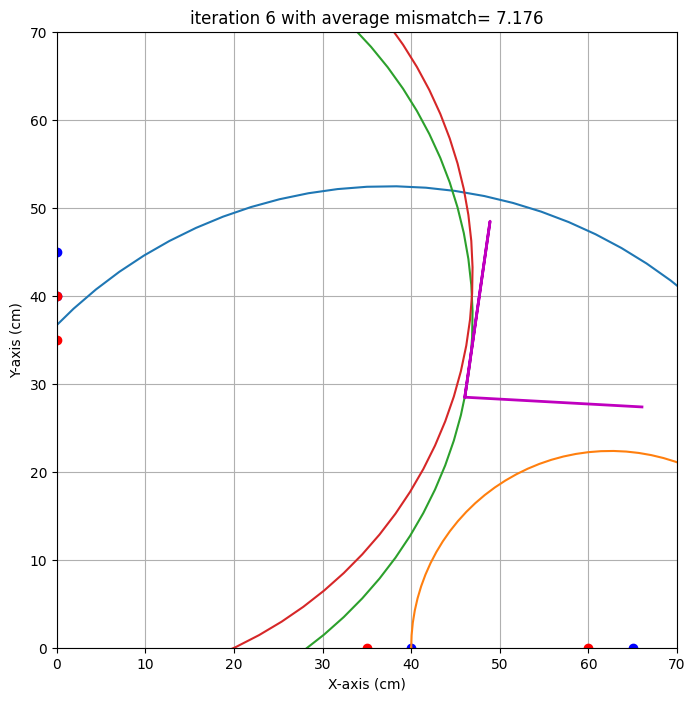

end iteration 6 with average mismatch= 7.176


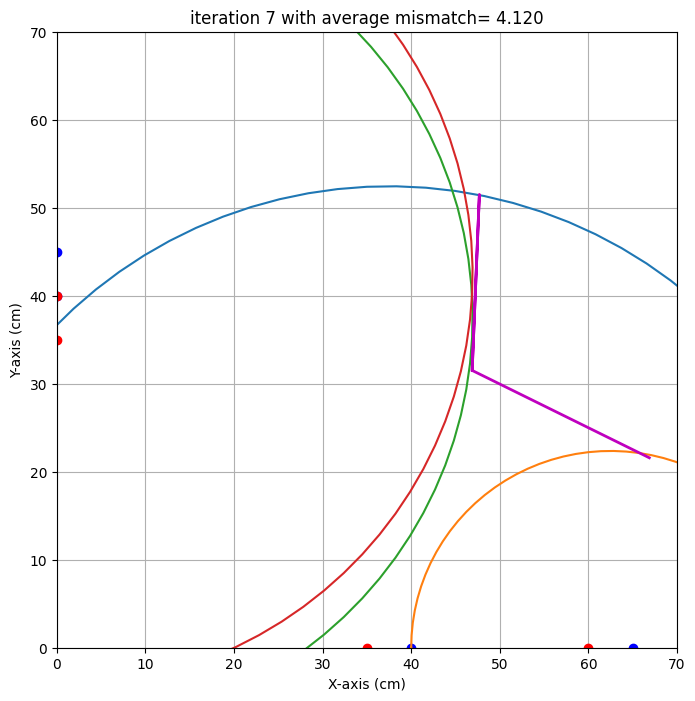

end iteration 7 with average mismatch= 4.120
end iteration 8 with average mismatch= 3.980
end iteration 9 with average mismatch= 3.918
end iteration 10 with average mismatch= 3.898
end iteration 11 with average mismatch= 3.886
end iteration 12 with average mismatch= 3.882
end iteration 13 with average mismatch= 3.882
end iteration 14 with average mismatch= 3.882
end iteration 15 with average mismatch= 3.846
end iteration 16 with average mismatch= 3.846
end iteration 17 with average mismatch= 3.846
end iteration 18 with average mismatch= 3.846
end iteration 19 with average mismatch= 3.846
end iteration 20 with average mismatch= 3.846
end iteration 21 with average mismatch= 3.846
end iteration 22 with average mismatch= 3.846
end iteration 23 with average mismatch= 3.846
end iteration 24 with average mismatch= 3.846
end iteration 25 with average mismatch= 3.846
end iteration 26 with average mismatch= 3.846
end iteration 27 with average mismatch= 3.846
end iteration 28 with average mismatc

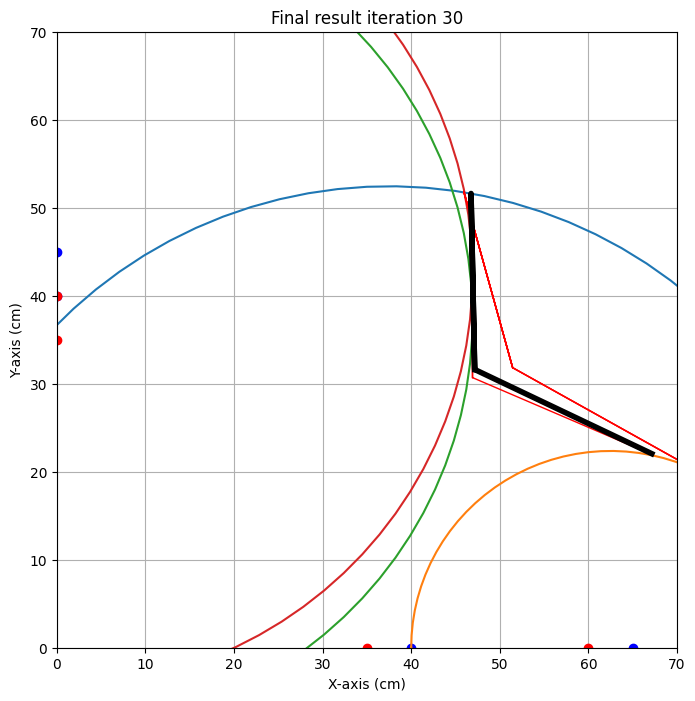

{'alpha': np.float64(-25.571540965136478), 'alpha_eps': np.float64(3.7521885241273196), 'beta': np.float64(-1.1751746754096752), 'beta_eps': np.float64(14.237560270085739), 'x0': np.float64(47.166626490966536), 'x0_eps': np.float64(4.2885135789625295), 'y0': np.float64(31.617969767813243), 'y0_eps': np.float64(0.9226503453110446)}


In [10]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [11]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Korné 
x0 target is : 52.0. Gevonden waarde: 45.2 cm met een standaardafwijking van 0.8 cm 
y0 target is : 40.0. Gevonden waarde: 25.0 cm met een standaardafwijking van 0.9 cm 
alpha target is : 109.0. Gevonden waarde: -5.1 graden met een standaardafwijking van 4.3 graad 
beta target is : 82.0. Gevonden waarde: 13.3 graden met een standaardafwijking van 11.1 graad 

Lucas 
x0 target is : 52.0. Gevonden waarde: 24.5 cm met een standaardafwijking van 0.7 cm 
y0 target is : 40.0. Gevonden waarde: 41.4 cm met een standaardafwijking van 0.9 cm 
alpha target is : 109.0. Gevonden waarde: -16.6 graden met een standaardafwijking van 7.1 graad 
beta target is : 82.0. Gevonden waarde: -30.4 graden met een standaardafwijking van 3.8 graad 

Vera 
x0 target is : 52.0. Gevonden waarde: 47.2 cm met een standaardafwijking van 4.3 cm 
y0 target is : 40.0. Gevonden waarde: 31.6 cm met een standaardafwijking van 0.9 cm 
alpha target is : 109.0. Gevonden waarde: -25.6 graden met een standaardafwijking van

## Opdracht 8: Iteratie1+.15:15.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](eindalgoritme.jpg)


In [12]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!
#geen extra code nodig

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  30   0  40  49.5
1  60   0  50   0  79.5
2   0  25   0  35  50.7
3   0  35   0  45  50.1
4  45   0  55   0  72.2
5  38   0  28   0  87.2


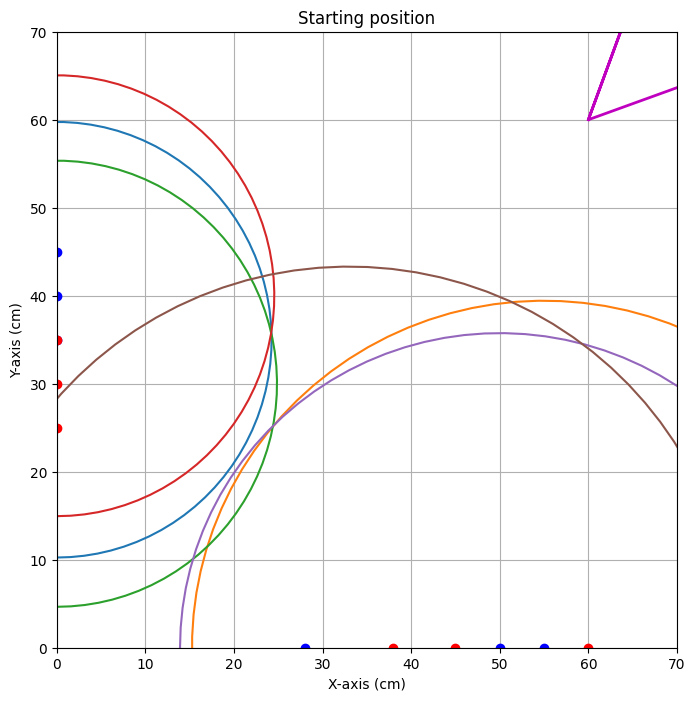


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=69.908


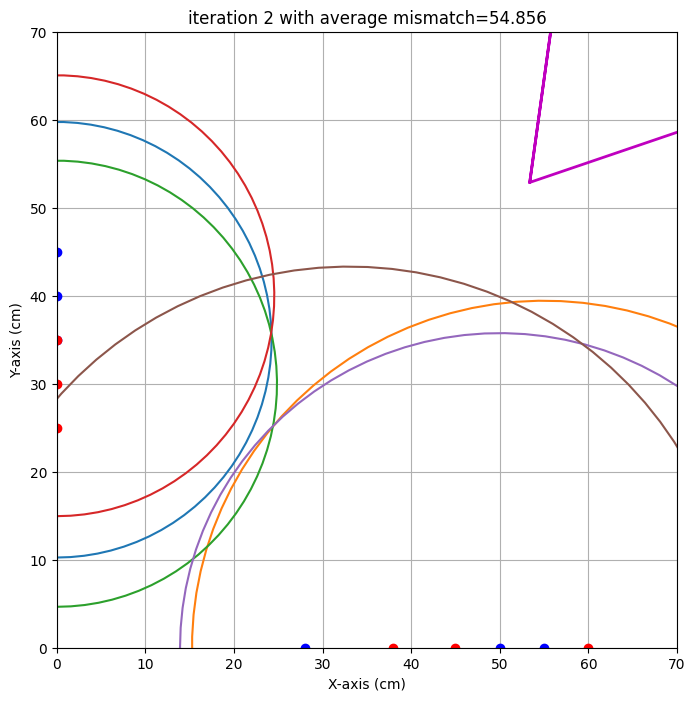

end iteration 2 with average mismatch=54.856


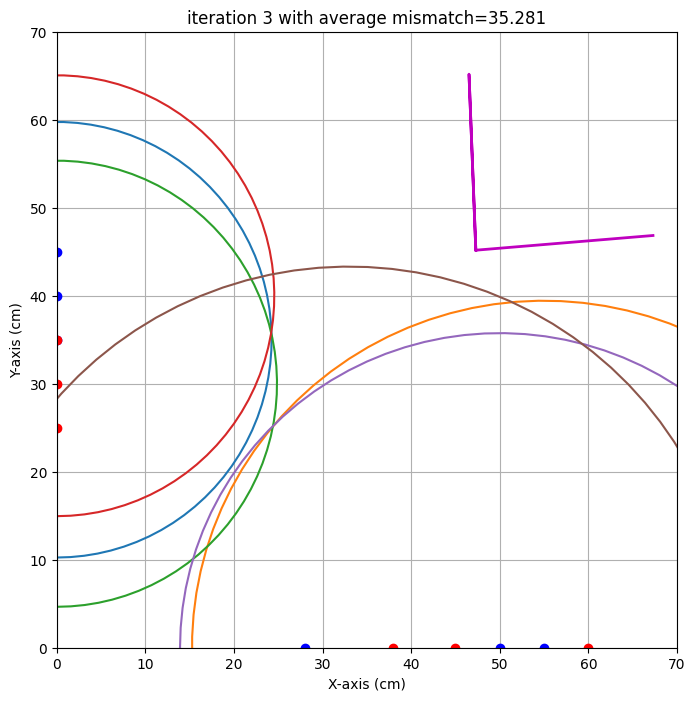

end iteration 3 with average mismatch=35.281


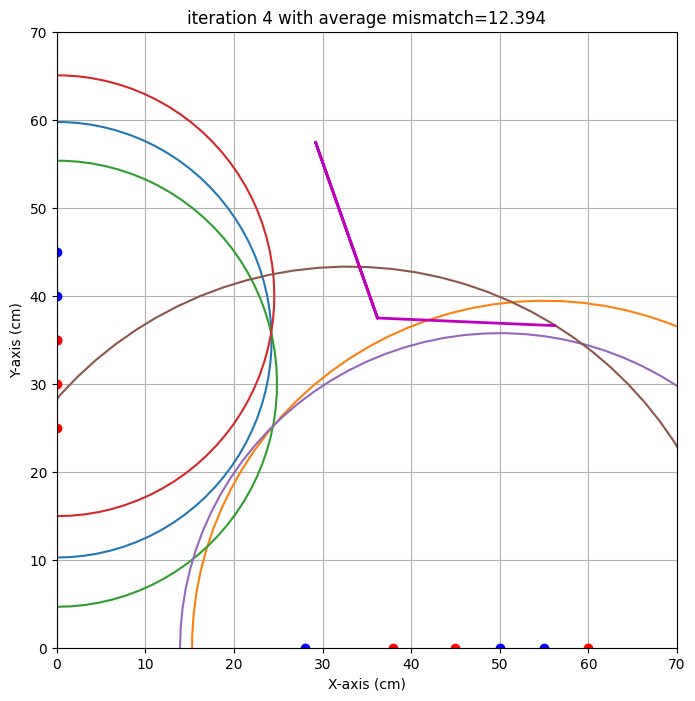

end iteration 4 with average mismatch=12.394


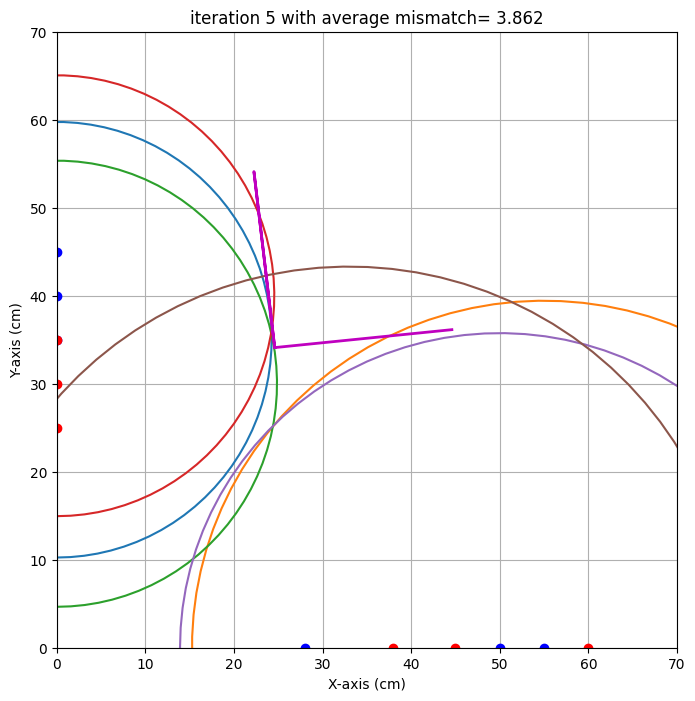

end iteration 5 with average mismatch= 3.862


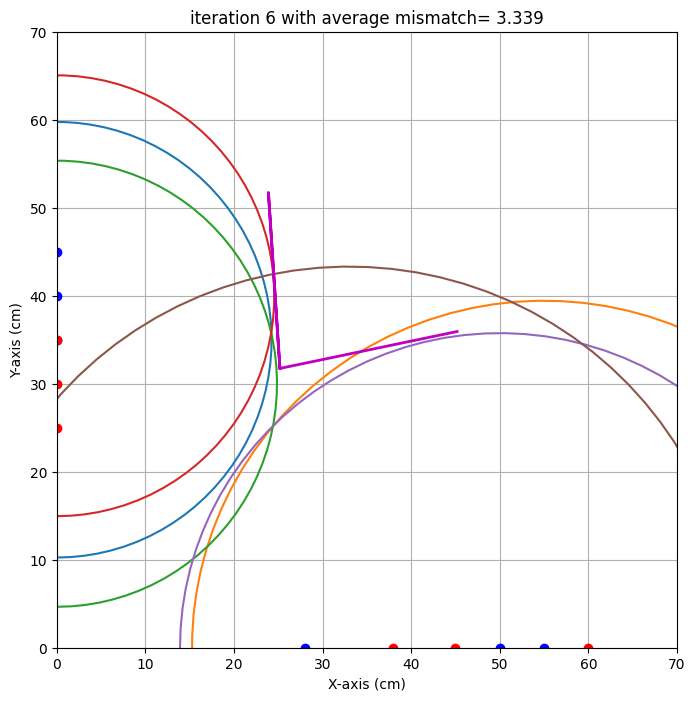

end iteration 6 with average mismatch= 3.339
end iteration 7 with average mismatch= 3.259
end iteration 8 with average mismatch= 3.014
end iteration 9 with average mismatch= 3.012
end iteration 10 with average mismatch= 3.011
end iteration 11 with average mismatch= 3.011
end iteration 12 with average mismatch= 3.011
end iteration 13 with average mismatch= 3.011
end iteration 14 with average mismatch= 3.011
end iteration 15 with average mismatch= 3.011
end iteration 16 with average mismatch= 3.011
end iteration 17 with average mismatch= 3.011
end iteration 18 with average mismatch= 3.011
end iteration 19 with average mismatch= 3.011
end iteration 20 with average mismatch= 3.011
end iteration 21 with average mismatch= 3.011
end iteration 22 with average mismatch= 3.011
end iteration 23 with average mismatch= 3.011
end iteration 24 with average mismatch= 3.011
end iteration 25 with average mismatch= 3.011
end iteration 26 with average mismatch= 3.011
end iteration 27 with average mismatch

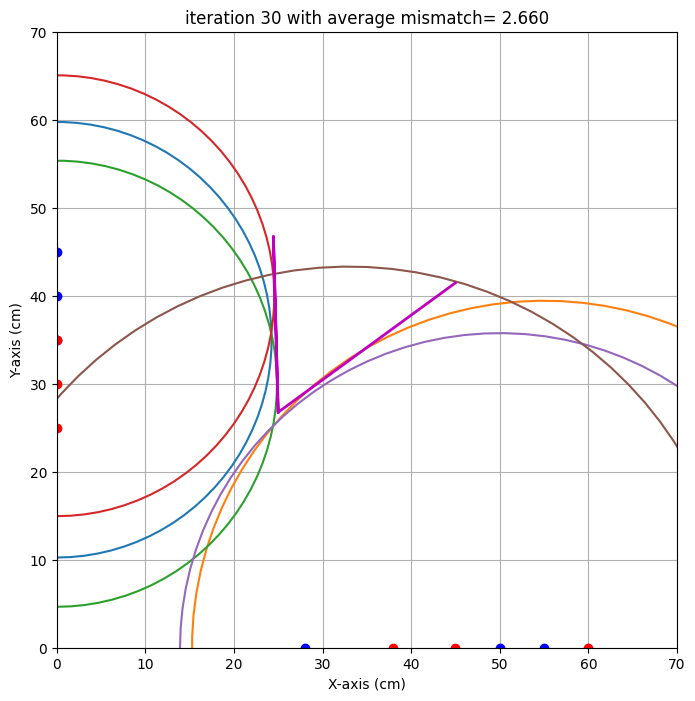

end iteration 30 with average mismatch= 2.660
###############################################################################
end of iteration  30
Best alpha=  36.30 with uncertainty=   5.24
Best beta =  -1.55 with uncertainty=   1.95
Best x0   =  24.98 with uncertainty=   0.39
Best y0   =  26.76 with uncertainty=   1.46
###############################################################################


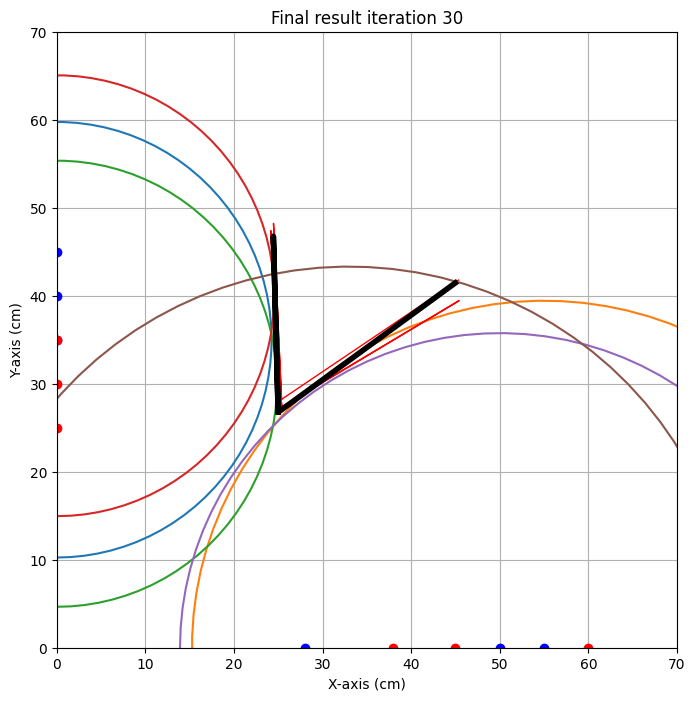

{'alpha': np.float64(36.303618414034126), 'alpha_eps': np.float64(5.24120585963913), 'beta': np.float64(-1.5549491810809615), 'beta_eps': np.float64(1.9477890601895531), 'x0': np.float64(24.98212921939309), 'x0_eps': np.float64(0.38865821404371204), 'y0': np.float64(26.76264272442571), 'y0_eps': np.float64(1.456685453585326)}
locatie 1 
x0 target is : 25.0. Gevonden waarde: 25.0 cm met een standaardafwijking van 0.4 cm 
y0 target is : 26.0. Gevonden waarde: 26.8 cm met een standaardafwijking van 1.5 cm 
alpha target is : 35.0. Gevonden waarde: 36.3 graden met een standaardafwijking van 5.2 graad 
beta target is : 0.0. Gevonden waarde: -1.6 graden met een standaardafwijking van 1.9 graad 



In [13]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':25,#zelf aanvullen,
                    'y0':26,#zelf aanvullen,
                    'alpha' : 35,#zelf aanvullen,
                    'beta' :0 #zelf aanvullen},
        #    'locatie 2':{'x0':#zelf aanvullen,
        #             'y0':#zelf aanvullen,
        #             'alpha' : #zelf aanvullen,
        #             'beta' : #zelf aanvullen}
            }}

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                            # [0,60,0,50,telt niet],
                            [0,30,0,40,49.5],
                            # [30,0,40,0,kan niet],
                            [60,0,50,0,79.5],
                            # [35,0,45,0,134.6],
                            [0,25,0,35,50.7],
                            [0,35,0,45,50.1],
                            # [25,0,35,0,kan niet],
                            [45,0,55,0,72.2],
                            # [0,27,0,37,],
                            # [0,33,0,43,],
                            [38,0,28,0,87.2],
                            # [32,0,42,0,]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  30   0  40   0  42.4
1   0  30   0  40  51.7
2   0  35   0  45  53.5
3  25   0  35   0  44.0
4  35   0  45   0  37.8
5  27   0  37   0  42.0
6  33   0  43   0  41.1
7   0  27   0  37  51.2
8   0  33   0  43  52.8


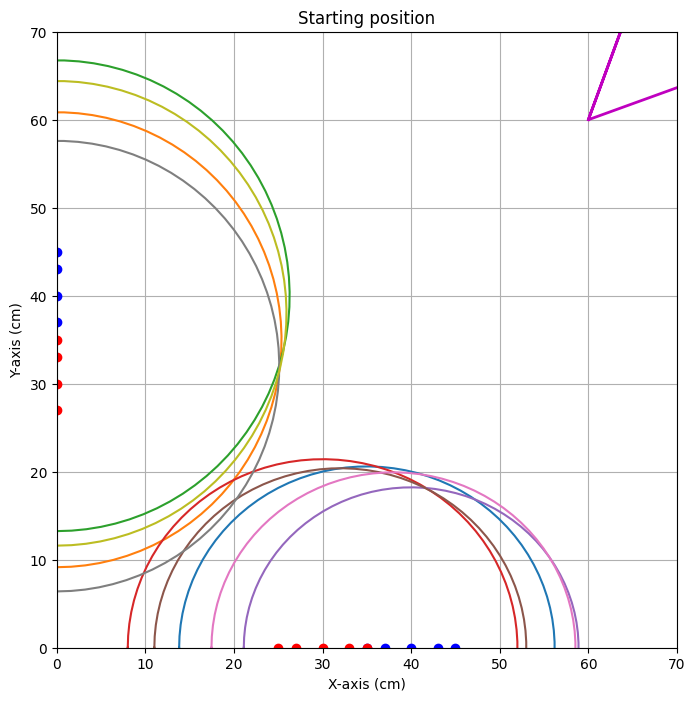


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=90.958


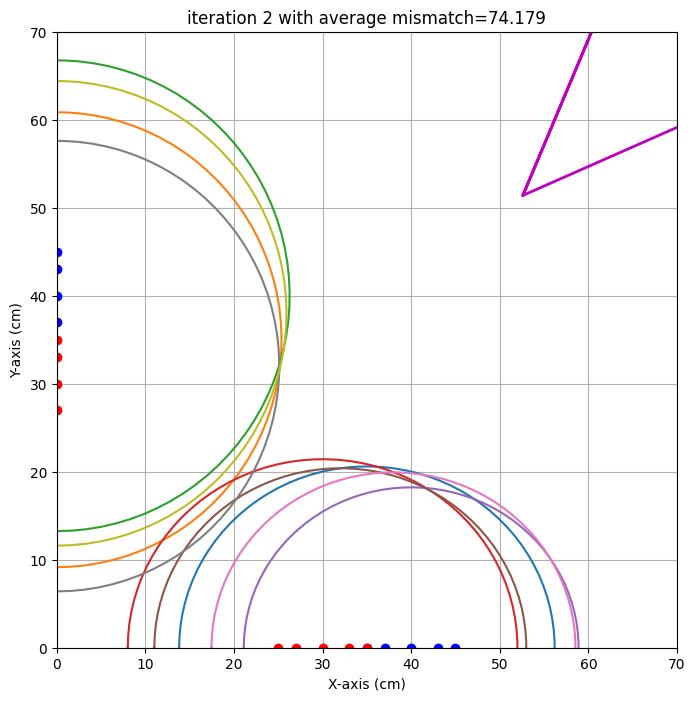

end iteration 2 with average mismatch=74.179


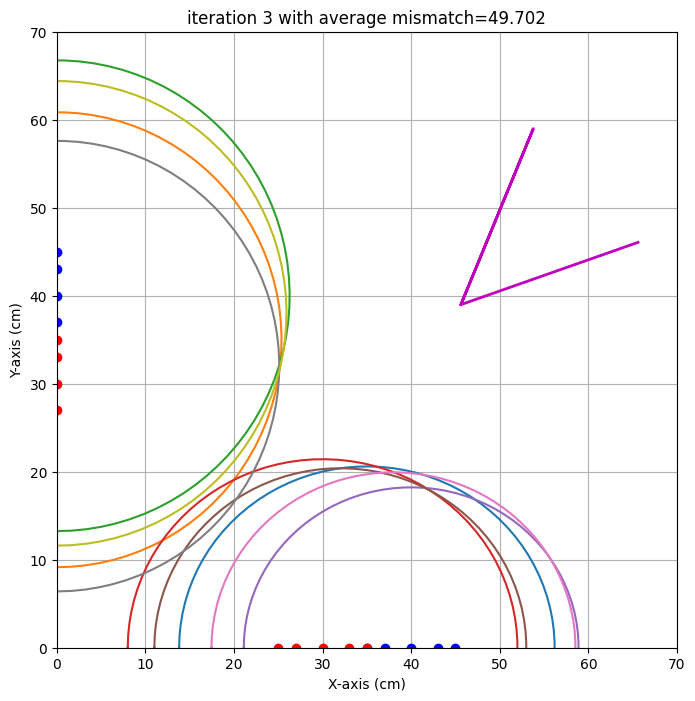

end iteration 3 with average mismatch=49.702


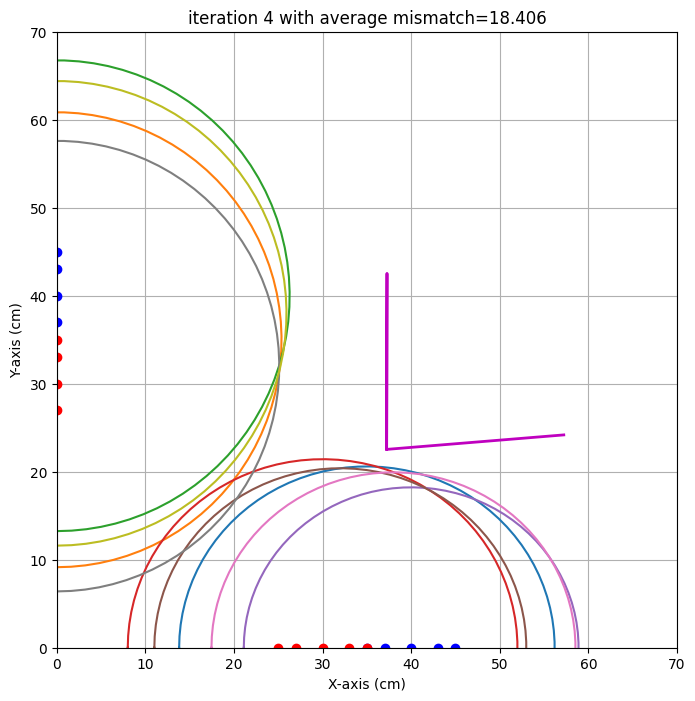

end iteration 4 with average mismatch=18.406


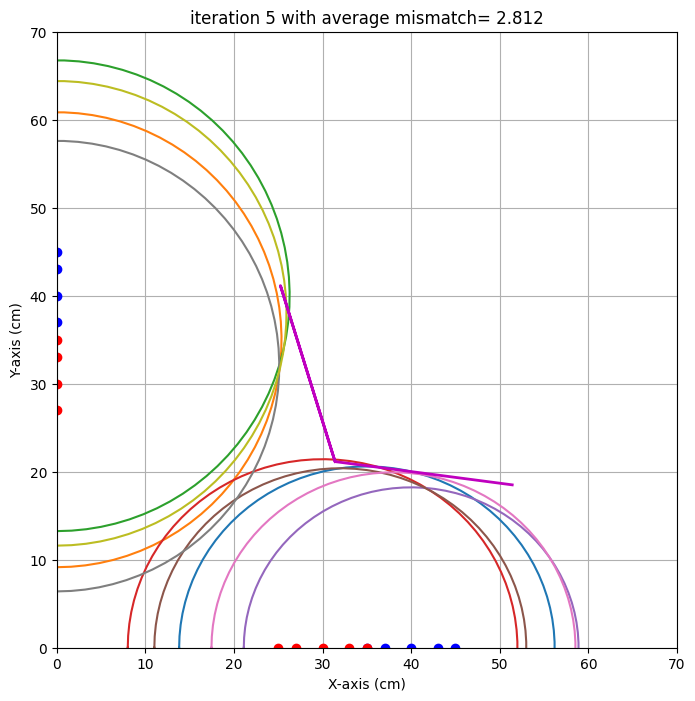

end iteration 5 with average mismatch= 2.812


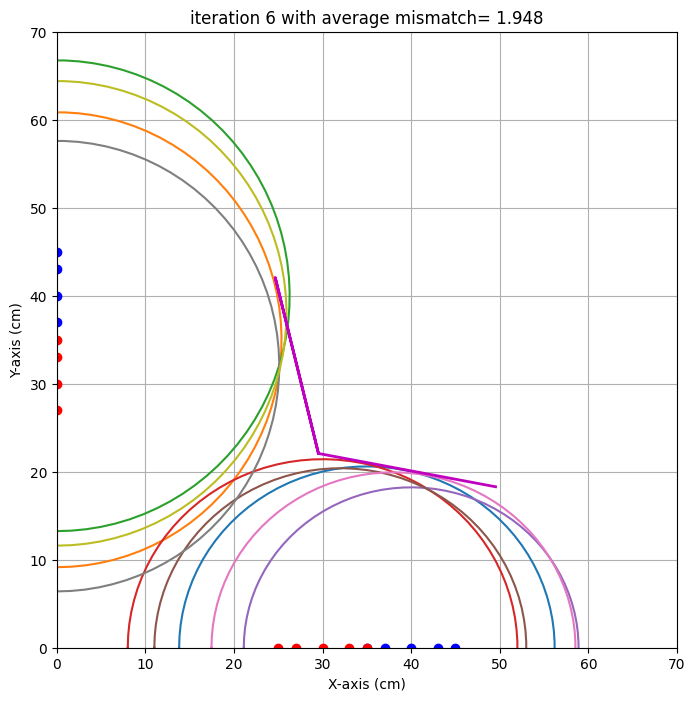

end iteration 6 with average mismatch= 1.948
end iteration 7 with average mismatch= 1.767


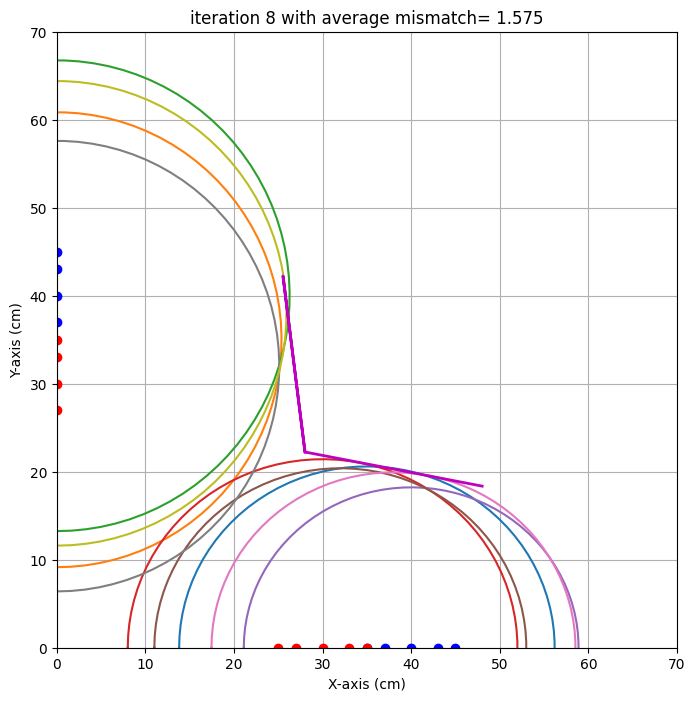

end iteration 8 with average mismatch= 1.575
end iteration 9 with average mismatch= 1.426
end iteration 10 with average mismatch= 1.415
end iteration 11 with average mismatch= 1.415
end iteration 12 with average mismatch= 1.415
end iteration 13 with average mismatch= 1.415
end iteration 14 with average mismatch= 1.415
end iteration 15 with average mismatch= 1.415
end iteration 16 with average mismatch= 1.415
end iteration 17 with average mismatch= 1.329
end iteration 18 with average mismatch= 1.324


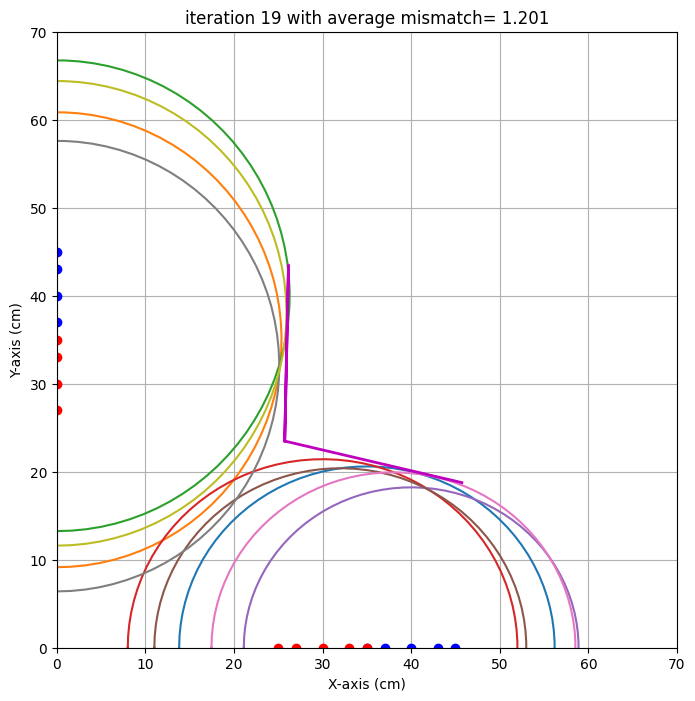

end iteration 19 with average mismatch= 1.201


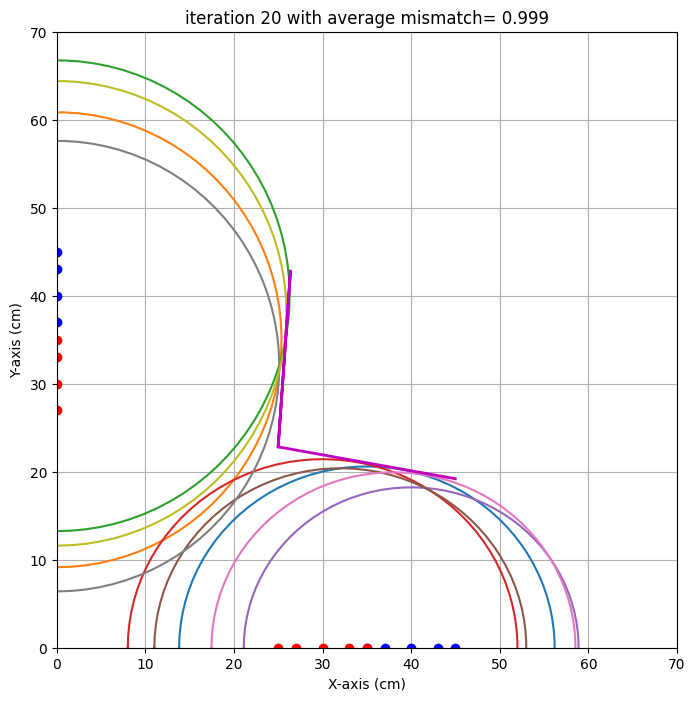

end iteration 20 with average mismatch= 0.999
end iteration 21 with average mismatch= 0.915


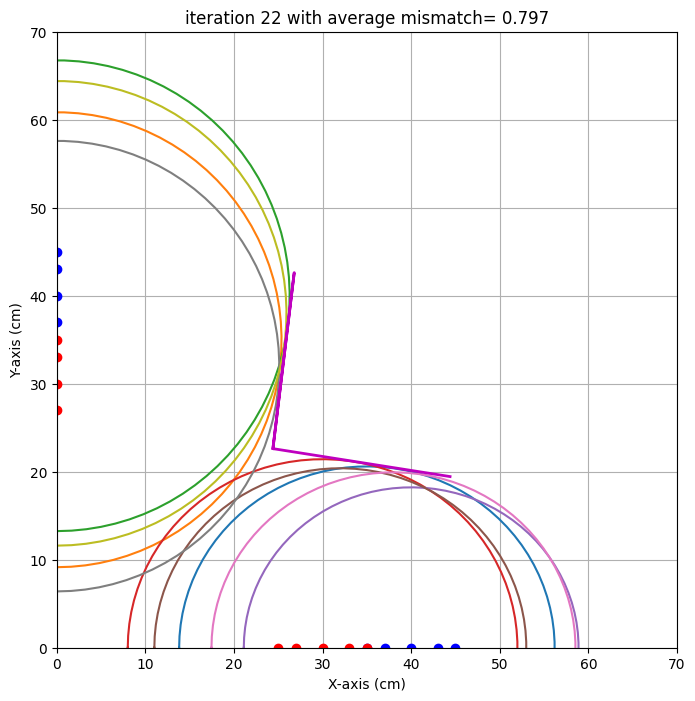

end iteration 22 with average mismatch= 0.797
end iteration 23 with average mismatch= 0.783
end iteration 24 with average mismatch= 0.779
end iteration 25 with average mismatch= 0.778
end iteration 26 with average mismatch= 0.743
end iteration 27 with average mismatch= 0.733
end iteration 28 with average mismatch= 0.730
end iteration 29 with average mismatch= 0.730
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.730
###############################################################################
end of iteration  30
Best alpha= -10.28 with uncertainty=   2.37
Best beta =   8.77 with uncertainty=   4.06
Best x0   =  23.99 with uncertainty=   0.72
Best y0   =  22.90 with uncertainty=   0.52
###############################################################################


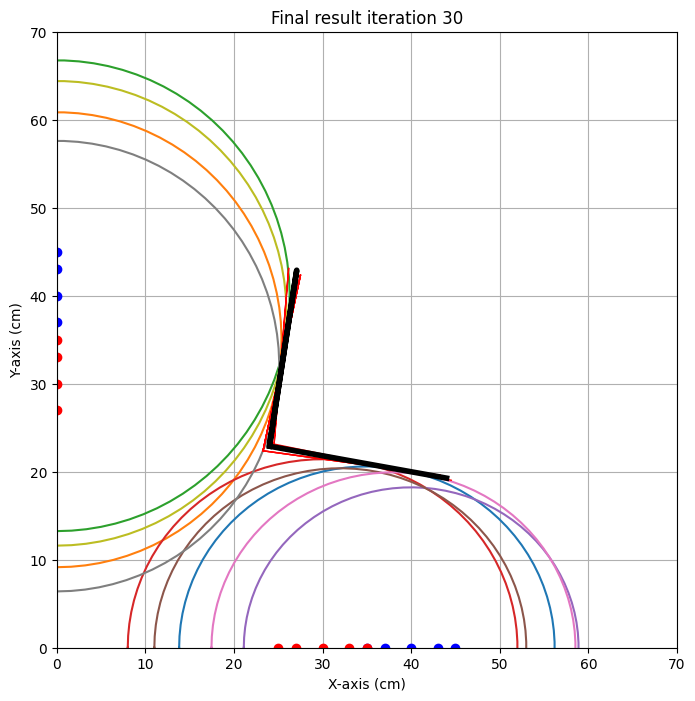

{'alpha': np.float64(-10.282654552709383), 'alpha_eps': np.float64(2.373053051617841), 'beta': np.float64(8.768431896754505), 'beta_eps': np.float64(4.061258711879715), 'x0': np.float64(23.991822576577192), 'x0_eps': np.float64(0.7167813552722038), 'y0': np.float64(22.900187624355343), 'y0_eps': np.float64(0.5231691352418473)}
test locatie 
x0 target is : 24.0. Gevonden waarde: 24.0 cm met een standaardafwijking van 0.7 cm 
y0 target is : 23.0. Gevonden waarde: 22.9 cm met een standaardafwijking van 0.5 cm 
alpha target is : 70.0. Gevonden waarde: -10.3 graden met een standaardafwijking van 2.4 graad 
beta target is : 111.0. Gevonden waarde: 8.8 graden met een standaardafwijking van 4.1 graad 



In [14]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 24, # zelf aanvullen,
                    'y0':  23,# zelf aanvullen,
                    'alpha' : 70, # zelf aanvullen,
                    'beta' :  111# zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [30,0,40,0,42.4],
                    # [60,0,50,0,niks],
                    [0,30,0,40,51.7],
                    # [0,60,0,50,63.6],
                    [0,35,0,45,53.5],
                    # [0,25,0,35,93.1],
                    [25,0,35,0,44],
                    [35,0,45,0,37.8],
                    [27,0,37,0,42],
                    [33,0,43,0,41.1],
                    [0,27,0,37,51.2],
                    [0,33,0,43,52.8]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](logaritmevera.jpg)

Bij dit algoritme was het idee dat als de bron en de ontvanger dichtbij elkaar stonden, de meting het accuraatst zou zijn. Dit bleek echter niet waar te zijn, dus hier zijn we niet verder mee gegaan.


Figuur: ![Alt](logaritmekorne.jpg)

Bij dit algoritme was het idee dat als de bron en de ontvanger op 10 cm van elkaar stonden, en dat zo de meting het accuraatst zou zijn. Dit bleek de meest ideale resultaten op te leveren, waardoor we hier mee zijn door gegaan.

Figuur: ![Alt](logaritmelucas.jpg)

Bij dit algoritme was het idee dat als de bron en de ontvanger ver weg van elkaar stonden, de meting het accuraatst zou zijn. Dit bleek echter niet waar te zijn, dus hier zijn we niet verder mee gegaan.

Figuur: ![Alt](eindalgoritme.jpg)

Omdat de 10 cm afstand het beste resultaat opleverde, hebben we dit iets verder uitgewerkt door de posities 5 en 3 centimeter te verplaatsen om een betere locatie te verkrijgen. Deze 12 metingen, gecombineerd met het verwijderen van de ongeldige resultaten bracht ons binnen de gewenste accuratie.